In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  ## better plots 
import sax  ## dizionario matrice scattering
from jax.typing import ArrayLike
import jax.numpy as jnp

In [2]:
from simphony.libraries import ideal
from simphony.libraries import siepic 

**Uso la guida d'onda "ideal". Ho bisogno di parametri quali: n_eff, n_g, wl0, wl**

In [3]:
ideal.waveguide?

Signature:
ideal.waveguide(
    *,
    wl: Union[jax.Array, numpy.ndarray, numpy.bool, numpy.number, bool, int, float, complex, jax._src.literals.TypedNdArray] = 1.55,
    wl0: float = 1.55,
    neff: float = 2.34,
    ng: float = 3.4,
    length: float = 10.0,
    loss: float = 0.0,
) -> dict[tuple[str, str], jaxtyping.Complex[Array, '...']]
Docstring:
A simple straight waveguide model.

Port names are "o0" and "o1".

Parameters
----------
wl : ArrayLike or float
    Wavelength in microns (default 1.55).
wl0 : float
    Center wavelength in microns (default 1.55).
neff : float
    Effective index (default 2.34).
ng : float
    Group index (default 3.4).
length : float
    Length in microns (default 10.0).
loss : float
    Loss in dB/cm (default 0.0).

Returns:
    A dictionary of scattering matrices.
File:      ~/miniconda3/lib/python3.13/site-packages/simphony/libraries/ideal.py
Type:      function

In [4]:
siepic.waveguide?

Signature:
siepic.waveguide(
    wl: Union[float, jax.Array] = 1.55,
    pol: Literal['te', 'tm'] = 'te',
    length: float = 0.0,
    width: float = 500.0,
    height: float = 220.0,
    loss: float = 0.0,
) -> dict[tuple[str, str], jaxtyping.Complex[Array, '...']]
Docstring:
Model for an waveguide optimized for TE polarized light at 1550
nanometers.

A waveguide easily connects other optical components within a circuit.

.. image:: /_static/images/ebeam_wg_integral_1550.png
    :alt: ebeam_bdc_te1550.png

Parameters
----------
pol : str, optional
    Polarization of the grating coupler. Must be either 'te' (default) or
    'tm'.
length : float, optional
    Waveguide length in microns (default 0).
width : float, optional
    Waveguide width in nanometers (default 500).
height : float, optional
    Waveguide height in nanometers (default 220).
loss : float, optional
    Loss of the waveguide in dB/cm (default 0).
sigma_ne : float, optional
    Standard deviation of the effective index

In [28]:
wg_1 = ideal.waveguide( wl = 1.5, length = 296.64)
wg_2 = siepic.waveguide( wl = 1.5, length = 296.64)

In [29]:
wg_1

{('o0', 'o1'): Array(-0.99170304-0.12854993j, dtype=complex128),
 ('o1', 'o0'): Array(-0.99170304-0.12854993j, dtype=complex128)}

In [30]:
wg_2

{('o0', 'o0'): Array([0.+0.j], dtype=complex128),
 ('o0', 'o1'): Array([-0.03319093-0.99944903j], dtype=complex128),
 ('o1', 'o0'): Array([-0.03319093-0.99944903j], dtype=complex128),
 ('o1', 'o1'): Array([0.+0.j], dtype=complex128)}

**Confronto la trasmittanza tra le guide**

In [23]:
S_par_wg2 = wg_2

In [24]:
Pow_1 = jnp.abs(S_par_wg1["o0", "o1"])**2

In [25]:
Pow_1

Array(1., dtype=float64)

In [26]:
circuit_wg1, info = sax.circuit(
    netlist = {
        "instances": {
            "wg_1":"waveguide",
            "wg_2":"waveguide",
        },
        "connections": {
            "wg_1, o1":"wg_2, o0",
        },
        "ports": {
            "in0": "wg_1, o0",
            "out0": "wg_2, o1",
        },
    },
        models={
    "waveguide": ideal.waveguide,
}
)

In [43]:
sim1 = ClassicalSim(circuit_wg1, wl=np.linspace(1.5, 1.6, 150), wg_1={"length": 150.0}, wg_2={"length": 150.0})
laser = sim.add_laser(ports=['in0'], power= 1.0, phase=jnp.pi)
detector = sim.add_detector(ports=['out0'])

In [44]:
result = sim1.run()
result.detectors['out0'].plot()

KeyError: 'out0'

In [45]:
#lg = (22.5, 25, 50, 100, 125, 150, 170, 220, 250, 280, 300)
wl=np.linspace(1.5, 1.6, 150)

In [41]:
S_1 = circuit_wg1(wl=wl, wg_1={"length": 150.0}, wg_2={"length": 35.0})

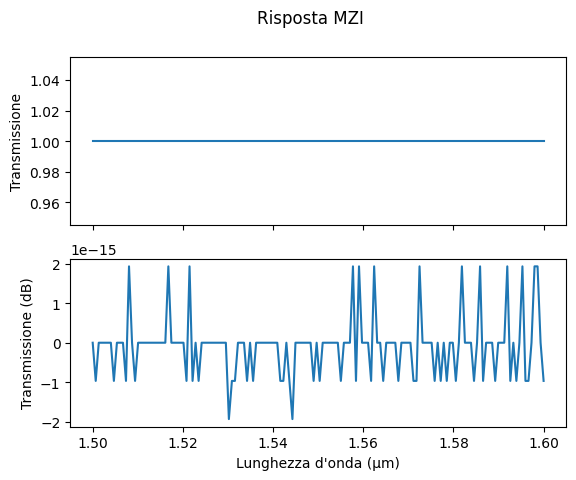

In [42]:
mag_1 = jnp.abs(S_1["out0", "in0"])**2 ## S_21

fig, axs = plt.subplots(2,1, sharex=True)
axs[0].plot(wl, mag_1)
axs[0].set_ylabel("Transmissione")
axs[1].plot(wl, 10*jnp.log10(mag_1))
axs[1].set_ylabel("Transmissione (dB)")
axs[1].set_xlabel("Lunghezza d'onda (µm)")
plt.suptitle("Risposta MZI")
plt.show()

In [39]:
print(S_1)

{('in0', 'in0'): Array(0.+0.j, dtype=complex128), ('in0', 'out0'): Array(-0.25065253+0.96807712j, dtype=complex128), ('out0', 'in0'): Array(-0.25065253+0.96807712j, dtype=complex128), ('out0', 'out0'): Array(0.+0.j, dtype=complex128)}


In [46]:
print (phase)

NameError: name 'phase' is not defined